# Data-harvesting MLflow analysis

Reference a training run, inspect its metric histories and checkpoints, then generate episode-level evaluation data for plots.

In [1]:
from data_harvesting.analysis import ExperimentRun

TRACKING_URI = "http://localhost:5000"
RUN_ID = "a221353db7fc421b9a6b821061b9fd8d"

run = ExperimentRun.from_id(RUN_ID, tracking_uri=TRACKING_URI)
# Alternatively:
# run = ExperimentRun.from_name("death", "6_mlp", tracking_uri=TRACKING_URI)

## Metrics

In [2]:
run.metric_names

('all_collected',
 'avg_collection_time',
 'avg_reward',
 'completion_time',
 'end_cause_ALL_AGENTS_INACTIVE',
 'end_cause_ALL_COLLECTED',
 'end_cause_NONE',
 'end_cause_STALLED',
 'end_cause_TIMEOUT',
 'episode_duration',
 'eval/all_collected',
 'eval/avg_collection_time',
 'eval/avg_reward',
 'eval/completion_time',
 'eval/end_cause_ALL_AGENTS_INACTIVE',
 'eval/end_cause_ALL_COLLECTED',
 'eval/end_cause_NONE',
 'eval/end_cause_STALLED',
 'eval/end_cause_TIMEOUT',
 'eval/episode_duration',
 'eval/max_reward',
 'eval/num_collected',
 'eval/num_dead',
 'eval/sum_reward',
 'loss_loss_actor',
 'loss_loss_value',
 'max_reward',
 'num_collected',
 'num_dead',
 'sps',
 'sum_reward')

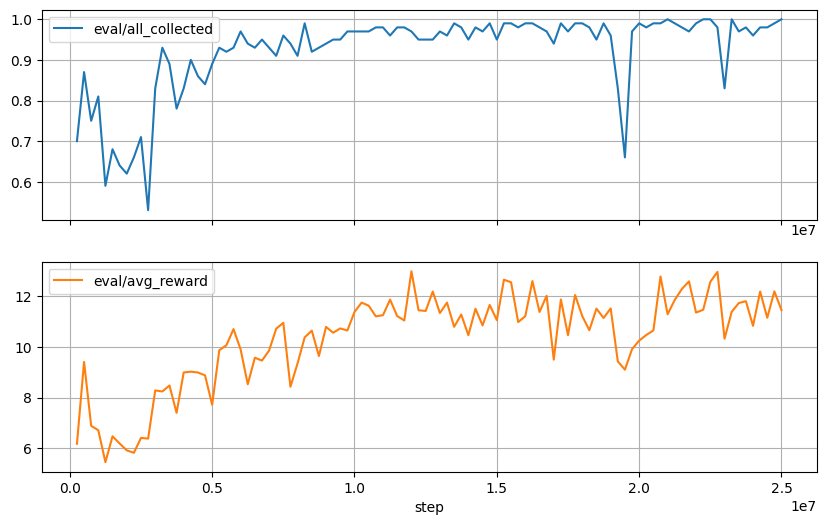

In [3]:
metrics = run.metrics(["eval/all_collected", "eval/avg_reward"])
metrics.plot(x="step", subplots=True, figsize=(10, 6), grid=True);

## Models and training-time evaluation metrics

In [4]:
models = run.models()
models_with_evaluation = run.models_with_metrics()
models_with_evaluation

,name,model_id,kind,step,step_inferred,creation_time,eval/all_collected,eval/avg_collection_time,eval/avg_reward,eval/completion_time,eval/end_cause_ALL_AGENTS_INACTIVE,eval/end_cause_ALL_COLLECTED,eval/end_cause_NONE,eval/end_cause_STALLED,eval/end_cause_TIMEOUT,eval/episode_duration,eval/max_reward,eval/num_collected,eval/num_dead,eval/sum_reward
0,policy_checkpoint_step_1000448,m-f0a36363d2254b7184f73f4e2ac214f4,checkpoint,1000448,False,2026-08-21 23:32:59.675000+00:00,0.81,55.717394,6.708434,134.12,0.0,81.0,0.0,19.0,0.0,24.77,31.6925,17.26,0.0,161.304084
1,policy_checkpoint_step_2000384,m-97ddfa06b97d41fb8fdbcc3b3b64d6ea,checkpoint,2000384,False,2026-08-22 00:40:18.014000+00:00,0.62,76.822215,5.912079,222.90,0.0,62.0,0.0,38.0,0.0,30.52,33.0000,17.11,0.0,157.789647
2,policy_checkpoint_step_3000320,m-9d1a8feb4a064d9b838e9d856f8e044c,checkpoint,3000320,False,2026-08-22 01:47:37.671000+00:00,0.83,47.442784,8.282883,120.74,0.0,83.0,0.0,17.0,0.0,23.89,33.0000,17.41,0.0,163.092988
3,policy_checkpoint_step_4000256,m-045f289ef83e47f8975b5ae0e331e9a2,checkpoint,4000256,False,2026-08-22 02:54:39.363000+00:00,0.83,34.409809,8.992483,115.52,0.0,83.0,0.0,17.0,0.0,20.03,34.2000,16.91,0.0,159.502099
4,policy_checkpoint_step_5000192,m-fd307207a7304221bd5fce2b72ab02a3,checkpoint,5000192,False,2026-08-22 04:01:37.536000+00:00,0.89,26.170101,7.717327,99.10,0.0,89.0,0.0,11.0,0.0,24.83,34.6000,18.69,0.0,175.472813
5,policy_checkpoint_step_6000128,m-131abd5b703f438cb03844a4fb502368,checkpoint,6000128,False,2026-08-22 05:08:34.213000+00:00,0.97,21.551870,9.902449,55.42,0.0,97.0,0.0,3.0,0.0,20.33,35.7000,18.81,0.0,177.942348
6,policy_checkpoint_step_7000064,m-14a9ac66418b4e1aaba3f66ea5e6a9d3,checkpoint,7000064,False,2026-08-22 06:15:27.375000+00:00,0.93,25.664683,9.860279,71.92,0.0,93.0,0.0,7.0,0.0,20.41,36.1000,18.16,0.0,172.644488
7,policy_checkpoint_step_8000000,m-5e29e47d4e024a3290a8128d9c432fe9,checkpoint,8000000,False,2026-08-22 07:22:23.002000+00:00,0.91,29.988956,9.351846,77.64,0.0,91.0,0.0,9.0,0.0,18.89,33.6000,16.75,0.0,157.479676
8,policy_checkpoint_step_9000448,m-e025222812854085b74b0ce498c2d50a,checkpoint,9000448,False,2026-08-22 08:29:14.720000+00:00,0.94,26.468488,10.795850,64.34,0.0,94.0,0.0,6.0,0.0,18.10,36.9000,18.02,0.0,171.583346
9,policy_checkpoint_step_10000384,m-8ac73bb6f5424eb2865e6a348c6269be,checkpoint,10000384,False,2026-08-22 09:36:03.286000+00:00,0.97,21.362860,11.386379,47.08,0.0,97.0,0.0,3.0,0.0,16.22,35.4000,17.28,0.0,163.043046


## Load and evaluate one checkpoint

Choose a step displayed in the checkpoint rows above. Use `run.final_model()` instead when the unnumbered final policy is desired.

In [5]:
CHECKPOINT_STEP = int(models.loc[models["kind"] == "checkpoint", "step"].iloc[-1])
checkpoint = run.checkpoint(CHECKPOINT_STEP)
policy = checkpoint.load()

In [8]:
episodes = checkpoint.evaluate(
    100,
    config_overrides={
        "death_scheduler": {
            "probability": 0.05
        }
    },
    seed=1000,
)
episodes.head()

,source_run_id,source_run_name,model_name,model_id,model_step,model_kind,model_step_inferred,run_index,scenario_key,num_agents,...,max_reward,sum_reward,avg_collection_time,episode_duration,completion_time,all_collected,num_collected,num_dead,cause,end_cause_label
0,a221353db7fc421b9a6b821061b9fd8d,5_deathless,policy_checkpoint_step_25000448,m-bab8ef0efe134679b52ec7d77c5eecd8,25000448,checkpoint,False,0,agents_4__sensors_3,4,...,20.0,27.666666,7.333333,5.0,12.0,1.0,3.0,0.0,2,ALL_COLLECTED
1,a221353db7fc421b9a6b821061b9fd8d,5_deathless,policy_checkpoint_step_25000448,m-bab8ef0efe134679b52ec7d77c5eecd8,25000448,checkpoint,False,1,agents_1__sensors_10,1,...,20.0,92.599998,24.000000,29.0,60.0,1.0,10.0,0.0,2,ALL_COLLECTED
2,a221353db7fc421b9a6b821061b9fd8d,5_deathless,policy_checkpoint_step_25000448,m-bab8ef0efe134679b52ec7d77c5eecd8,25000448,checkpoint,False,2,agents_3__sensors_7,3,...,20.0,67.571426,11.714286,11.0,24.0,1.0,7.0,0.0,2,ALL_COLLECTED
3,a221353db7fc421b9a6b821061b9fd8d,5_deathless,policy_checkpoint_step_25000448,m-bab8ef0efe134679b52ec7d77c5eecd8,25000448,checkpoint,False,3,agents_8__sensors_12,8,...,40.0,118.416664,8.000000,11.0,24.0,1.0,12.0,0.0,2,ALL_COLLECTED
4,a221353db7fc421b9a6b821061b9fd8d,5_deathless,policy_checkpoint_step_25000448,m-bab8ef0efe134679b52ec7d77c5eecd8,25000448,checkpoint,False,4,agents_1__sensors_18,1,...,20.0,161.555557,31.333334,36.0,74.0,1.0,18.0,0.0,2,ALL_COLLECTED


In [10]:
episodes.groupby(["model_step"])["all_collected"].agg(["mean", "std", "count"])

,mean,std,count
model_step,,,
25000448,0.99,0.1,100
